# BC04 — Deep Learning : analyse de sentiment sur du texte

**Objectif RNCP :** prédire à partir de données **non structurées** (ici du texte), là où BC03
travaillait sur un tableau de colonnes numériques.

On utilise le jeu **IMDB** (50 000 critiques de films en anglais, étiquetées *positive* / *negative*),
intégré à Keras. Un réseau **Embedding + LSTM** apprend à lire une critique mot à mot et à décider
si elle est positive ou négative — aucune règle n'est écrite à la main.

Ce notebook déroule le même pipeline que `run.py`, mais à plat, cellule par cellule, pour
l'explication. Durée d'entraînement : ~1 minute (on travaille sur un sous-échantillon).

## Imports et paramètres

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

%matplotlib inline
tf.random.set_seed(42)

# Ces valeurs sont identiques a commun/config.py -> ParametresDL
NB_MOTS = 10000          # on ne garde que les 10 000 mots les plus frequents
LONGUEUR = 200           # chaque critique est ramenee a 200 mots
TAILLE_EMBEDDING = 32    # chaque mot devient un vecteur de 32 nombres
UNITES_LSTM = 32         # taille de la memoire du LSTM
DROPOUT = 0.3
EPOCHS = 5
BATCH_SIZE = 128
TAILLE_ECHANTILLON = 6000  # sous-echantillon pour une demo rapide

## 1. Chargement du jeu de données IMDB

`imdb.load_data()` renvoie 2 tuples `(critiques, labels)`. Chaque critique est **déjà une liste
d'entiers** : chaque entier est le rang d'un mot dans le vocabulaire (`1` = mot le plus fréquent).
Le label vaut `0` (critique négative) ou `1` (critique positive).

Au tout premier appel, Keras télécharge le fichier (~17 Mo) puis le met en cache.

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NB_MOTS)

print(f"Train set complet : {X_train.shape}")
print(f"Test set complet  : {X_test.shape}")
print(f"Repartition train : {np.bincount(y_train)}  (0 = negatif, 1 = positif)")
print(f"Une critique = liste d'entiers : {list(X_train[0][:12])} ...")

# Sous-echantillon pour un entrainement rapide en demonstration (le principe reste identique)
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(X_train), TAILLE_ECHANTILLON, replace=False)
idx_te = rng.choice(len(X_test), TAILLE_ECHANTILLON // 3, replace=False)
X_train, y_train = X_train[idx_tr], y_train[idx_tr]
X_test, y_test = X_test[idx_te], y_test[idx_te]
print(f"\nApres sous-echantillonnage : {len(X_train)} train / {len(X_test)} test")

Train set complet : (25000,)
Test set complet  : (25000,)
Repartition train : [12500 12500]  (0 = negatif, 1 = positif)
Une critique = liste d'entiers : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468] ...

Apres sous-echantillonnage : 6000 train / 2000 test


## 2. À quoi ressemble une critique ?

Les critiques sont stockées sous forme de nombres. On peut retrouver le texte grâce au dictionnaire
`mot -> index` fourni par Keras (les 3 premiers index sont réservés : `<pad>`, `<start>`, `<unk>`).

In [3]:
index_mots = imdb.get_word_index()
index_inverse = {i + 3: mot for mot, i in index_mots.items()}
index_inverse[0], index_inverse[1], index_inverse[2] = "<pad>", "<start>", "<unk>"

def decoder(sequence):
    return " ".join(index_inverse.get(i, "?") for i in sequence)

print(f"Label = {y_train[0]} (-> {'positive' if y_train[0] else 'negative'})\n")
print(decoder(X_train[0])[:500], "...")

Label = 1 (-> positive)

<start> this is a <unk> look at <unk> life back when he still a hyper 20 something the real home videos of al as a kid are great and the commentary from his real life parents gives a nice glimpse of just how weird al wound up as screwed up as he is this video is a must own for any devoted al <unk> ...


## 3. Distribution des longueurs de critiques

Les critiques n'ont pas toutes la même longueur. On visualise la distribution pour choisir une
longueur de troncature raisonnable (ici 200 mots : ça couvre la majorité des critiques sans les
allonger inutilement).

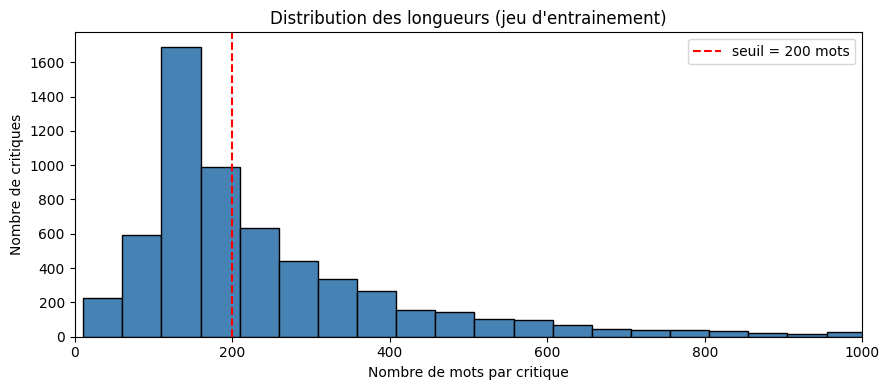

Longueur mediane : 181 mots  |  95e percentile : 615 mots


In [4]:
longueurs = [len(c) for c in X_train]

plt.figure(figsize=(9, 4))
plt.hist(longueurs, bins=50, color="steelblue", edgecolor="black")
plt.axvline(LONGUEUR, color="red", linestyle="--", label=f"seuil = {LONGUEUR} mots")
plt.xlabel("Nombre de mots par critique")
plt.ylabel("Nombre de critiques")
plt.title("Distribution des longueurs (jeu d'entrainement)")
plt.xlim(0, 1000)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Longueur mediane : {int(np.median(longueurs))} mots  |  95e percentile : {int(np.percentile(longueurs, 95))} mots")

## 4. Preprocessing : ramener toutes les critiques à la même longueur

Un réseau de neurones attend des entrées de taille fixe. `pad_sequences` tronque les critiques
trop longues et complète les trop courtes avec des `0` (`<pad>`), pour obtenir un tableau
rectangulaire `(nb_critiques, 200)`.

In [5]:
X_train_pad = pad_sequences(X_train, maxlen=LONGUEUR)
X_test_pad = pad_sequences(X_test, maxlen=LONGUEUR)

print(f"Avant : critiques de longueurs variables ({len(X_train[0])}, {len(X_train[1])}, {len(X_train[2])}, ...)")
print(f"Apres : {X_train_pad.shape}  (toutes a {LONGUEUR} mots)")
print(f"\nExemple (debut de la 1re critique paddee) : {X_train_pad[0][:20]}")

Avant : critiques de longueurs variables (64, 135, 157, ...)
Apres : (6000, 200)  (toutes a 200 mots)

Exemple (debut de la 1re critique paddee) : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 5. Le modèle : Embedding + LSTM + Dense

Trois briques empilées :

1. **Embedding** — transforme chaque mot (un entier) en un vecteur de `32` nombres qui capture un
   peu de son sens : deux mots proches auront des vecteurs proches. Poids appris pendant
   l'entraînement.
   `10 000 mots x 32 = 320 000 paramètres`.
2. **LSTM** (*Long Short-Term Memory*) — lit la critique **mot après mot** en gardant une mémoire
   du contexte. Indispensable pour du texte, où l'ordre change le sens (« *pas bien* » ≠ « *bien* »).
3. **Dense** (1 neurone, activation *sigmoïde*) — sortie finale : une probabilité entre `0`
   (négatif) et `1` (positif).

In [6]:
model = keras.Sequential([
    layers.Input(shape=(LONGUEUR,), name="entree"),
    layers.Embedding(input_dim=NB_MOTS, output_dim=TAILLE_EMBEDDING, name="embedding"),
    layers.LSTM(UNITES_LSTM, dropout=DROPOUT, name="lstm"),
    layers.Dense(1, activation="sigmoid", name="sortie"),
], name="sentiment_LSTM")

model.summary()

Model: "sentiment_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Configuration de l'entraînement

- **loss** : `binary_crossentropy` (2 classes)
- **optimizer** : `adam`
- **métrique suivie** : `accuracy`

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## 7. Entraînement

5 passages (*epochs*) sur les données, par paquets de 128 critiques. On donne le jeu de test comme
**validation** pour surveiller l'accuracy sur des données jamais vues à chaque epoch.

In [8]:
history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=2,  # 1 ligne par epoch
)

Epoch 1/5


47/47 - 7s - 152ms/step - accuracy: 0.5993 - loss: 0.6772 - val_accuracy: 0.7050 - val_loss: 0.5881


Epoch 2/5


47/47 - 5s - 101ms/step - accuracy: 0.7777 - loss: 0.4960 - val_accuracy: 0.8150 - val_loss: 0.4194


Epoch 3/5


47/47 - 5s - 98ms/step - accuracy: 0.8785 - loss: 0.3111 - val_accuracy: 0.8370 - val_loss: 0.3703


Epoch 4/5


47/47 - 5s - 97ms/step - accuracy: 0.9370 - loss: 0.1908 - val_accuracy: 0.8360 - val_loss: 0.3784


Epoch 5/5


47/47 - 5s - 97ms/step - accuracy: 0.9570 - loss: 0.1386 - val_accuracy: 0.8345 - val_loss: 0.4024


## 8. Courbes de loss et d'accuracy

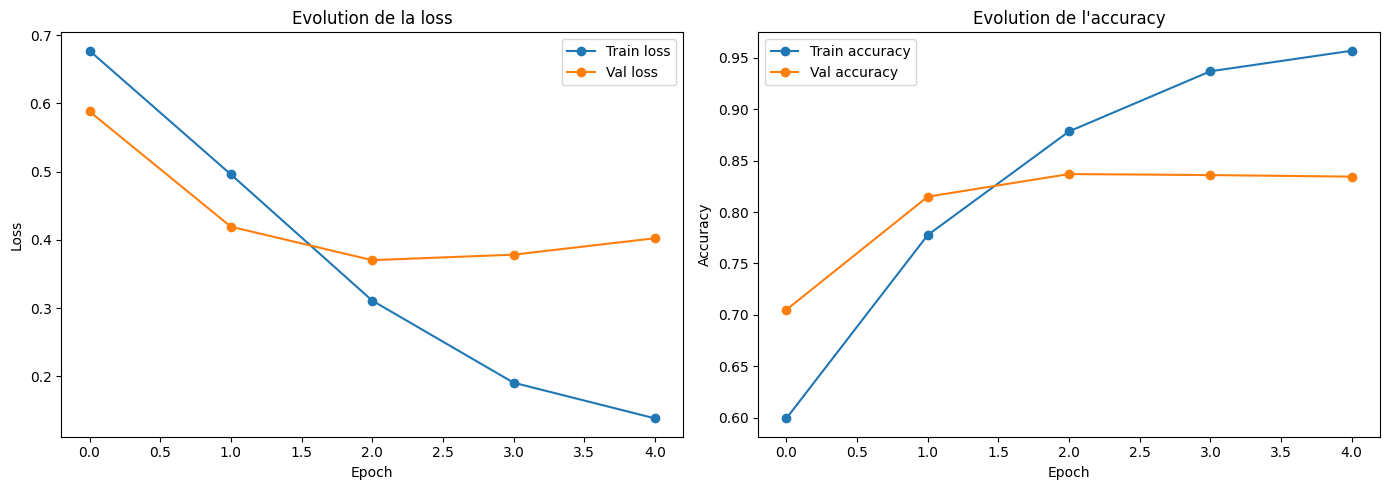

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], marker="o", label="Train loss")
ax1.plot(history.history["val_loss"], marker="o", label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Evolution de la loss")
ax1.legend()

ax2.plot(history.history["accuracy"], marker="o", label="Train accuracy")
ax2.plot(history.history["val_accuracy"], marker="o", label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Evolution de l'accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Évaluation sur le jeu de test

`model.predict` renvoie une probabilité ; on décide « positif » au-dessus de `0.5`. On regarde
l'accuracy (proportion de bonnes réponses), le F1-score et l'AUC-ROC.

In [10]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
y_proba = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_proba > 0.5).astype(int)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"F1-score      : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_test, y_proba):.4f}")

Test loss     : 0.4024
Test accuracy : 0.8345
F1-score      : 0.8309
AUC-ROC       : 0.9161


## 10. Matrice de confusion

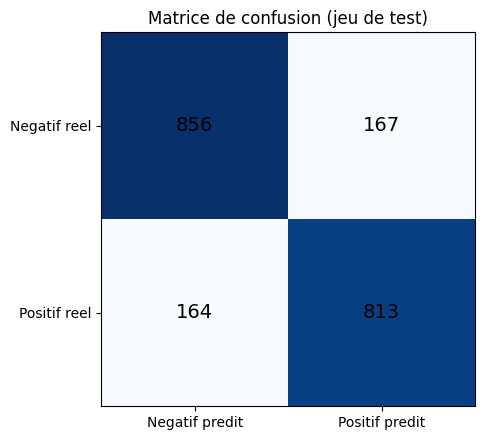

In [11]:
matrice = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(matrice, cmap="Blues")
ax.set_xticks([0, 1], ["Negatif predit", "Positif predit"])
ax.set_yticks([0, 1], ["Negatif reel", "Positif reel"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, matrice[i, j], ha="center", va="center", fontsize=14)
ax.set_title("Matrice de confusion (jeu de test)")
plt.tight_layout()
plt.show()

## 11. Prédictions sur des critiques réelles

On redécode 5 critiques du jeu de test en texte et on affiche la prédiction du modèle.

In [12]:
for i in range(5):
    reel = "positif" if y_test[i] == 1 else "negatif"
    predit = "positif" if y_pred[i] == 1 else "negatif"
    marque = "OK    " if reel == predit else "ERREUR"
    print(f"[{marque}] reel = {reel:7s} | predit = {predit:7s} (probabilite = {y_proba[i]:.2f})")
    print(f'   "{decoder(X_test[i])[:200]}..."\n')

[ERREUR] reel = negatif | predit = positif (probabilite = 0.82)
   "<start> purchased this film for one dollar and figured i could never go wrong my big mistake was watching it enjoyed the acting of ice t and the <unk> which gave lots of class to this film about los a..."

[ERREUR] reel = positif | predit = negatif (probabilite = 0.43)
   "<start> i own this movie i am actually from the same town as the brother directors but that doesn't make the film any better but if one night you wanna watch something not serious and don't have and h..."

[OK    ] reel = positif | predit = positif (probabilite = 0.94)
   "<start> a fairly typical australian movie where the underdog saves the day <unk> of himself i guess there is no real reason to see this <unk> if you have seen the castle or the dish it still leaves yo..."

[OK    ] reel = negatif | predit = negatif (probabilite = 0.05)
   "<start> i am working at a video store so i got to see this one for free thank god had i paid for it my review 

## 12. Sauvegarde

Même fichier que celui produit par `blocs/bc04_deep_learning/run.py`, réutilisable par le notebook
de soutenance et la démo BC05.

In [13]:
import json
from pathlib import Path

dossier_modeles = next(p / "modeles" for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
dossier_modeles.mkdir(exist_ok=True)

model.save(dossier_modeles / "deep_learning_sentiment.keras")

metriques = {
    "accuracy": float(test_acc),
    "f1_score": float(f1_score(y_test, y_pred)),
    "auc_roc": float(roc_auc_score(y_test, y_proba)),
}
with open(dossier_modeles / "deep_learning_sentiment_metadata.json", "w", encoding="utf-8") as f:
    json.dump({"nom_modele": "deep_learning_sentiment", "metriques": metriques,
               "architecture": "Embedding + LSTM + Dense", "dataset": "IMDB (sentiment, texte)"},
              f, indent=2, ensure_ascii=False)

print("Sauvegarde :", dossier_modeles / "deep_learning_sentiment.keras")
print("Metriques  :", metriques)

Sauvegarde :

 C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc\modeles\deep_learning_sentiment.keras
Metriques  : {'accuracy': 0.8345000147819519, 'f1_score': 0.8308635666836995, 'auc_roc': 0.9160625971138732}


## Ce qu'il faut retenir

- Données **non structurées** (texte brut) → on ne peut pas les donner telles quelles à un modèle :
  il faut les **encoder en nombres** (index de mots) puis les **mettre à longueur fixe** (`pad_sequences`).
- L'**Embedding** apprend une représentation vectorielle des mots ; le **LSTM** lit la séquence en
  gardant le contexte ; la sortie **sigmoïde** donne une probabilité.
- Résultat sur le jeu de test : accuracy ≈ **0,83**, AUC-ROC ≈ **0,92** — le modèle a réellement
  appris à distinguer un avis positif d'un avis négatif, sans aucune règle écrite à la main.
- `blocs/bc04_deep_learning/run.py` fait exactement la même chose en une commande (mêmes valeurs,
  `commun/config.py::ParametresDL`).